# Correlation of LSD Tissue Concentration With Cognitive Performance  
### Linear Regression Analysis (Wagner et al., 1968)

This notebook analyzes the relationship between **tissue concentration of LSD-25** and **average arithmetic test performance** in human subjects.  
Using linear regression, we evaluate how increasing LSD levels affect cognitive ability.

**Key Findings:**
- Strong negative correlation between LSD concentration and math performance  
- Regression slope (θ₁): -9.01  
- Intercept: 89.12  
- R² = 0.878 → LSD concentration explains ~87.8% of score variance

Higher LSD concentration is associated with **lower cognitive performance**, indicating a harmful effect on mental processing.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

## 1. Loading the Dataset

The dataset includes:

- **Time_Delay_in_Minutes** — time after LSD administration  
- **LSD_ppm** — tissue concentration of LSD  
- **Avg_Math_Test_Score** — average arithmetic test score  

This dataset originates from research conducted in 1968 examining the drug’s physiological and behavioral effects.


In [43]:
data = pd.read_csv('lsd_math_score_data.csv')
data.head()

,Time_Delay_in_Minutes,LSD_ppm,Avg_Math_Test_Score
0,5,1.17,78.93
1,15,2.97,58.20
2,30,3.26,67.47
3,60,4.69,37.47
4,120,5.83,45.65


## 2. Selecting Features

We extract the input (LSD concentration) and output (math score) variables for modeling.


In [37]:
time = data[['Time_Delay_in_Minutes']]
LSD = data[['LSD_ppm']]
score = data[['Avg_Math_Test_Score']]

## 3. Exploratory Data Visualization

First we visualize how LSD concentration changes over time.


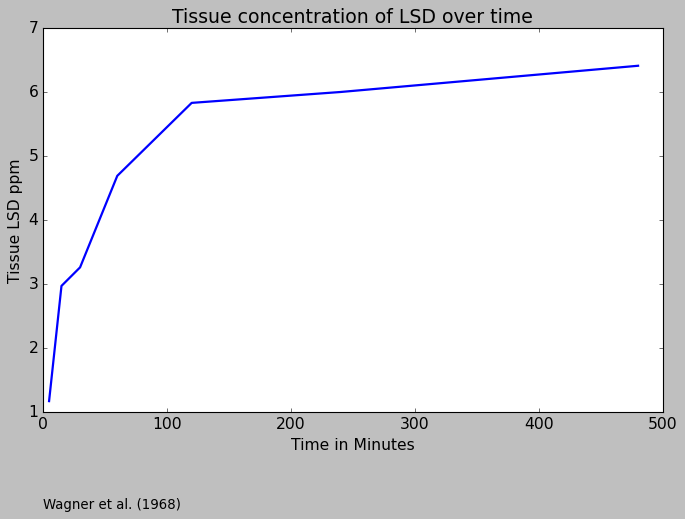

In [45]:
%matplotlib inline

plt.figure(figsize=(10,6))
plt.title('Tissue concentration of LSD over time', fontsize=17)
plt.xlabel('Time in Minutes', fontsize=14)
plt.ylabel('Tissue LSD ppm', fontsize=14)
plt.text(x=0, y=-0.5, s='Wagner et al. (1968)', fontsize=12)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.ylim(1,7)
plt.xlim(0,500)

plt.style.use('classic')
plt.plot(time, LSD, linewidth=2)
plt.show()

## 4. Linear Regression Model

We fit a simple linear regression model where:

\[
\text{Score} = \theta_0 + \theta_1 (\text{LSD concentration})
\]

We expect a **negative slope**, indicating reduced cognitive performance with increased LSD concentration.


In [46]:
regr = LinearRegression()
regr.fit(LSD, score)

print('Theta1 : ', regr.coef_[0][0])
print('Intercept: ', regr.intercept_[0])
print('R-Square: ', regr.score(LSD, score))

Theta1 :  -9.009466415296783
Intercept:  89.12387376799306
R-Square:  0.8778349707775888


## 5. Model Predictions

In [47]:
predicted_score = regr.predict(LSD)

## 6. Regression Line Visualization

The regression line shows the estimated relationship between LSD concentration and arithmetic performance.

### Interpretation:
- The **negative slope (-9.01)** indicates that performance decreases as LSD concentration increases.
- The **high R² (0.878)** shows strong explanatory power.
- Cognitive impairment appears strongly linked to LSD tissue concentration.

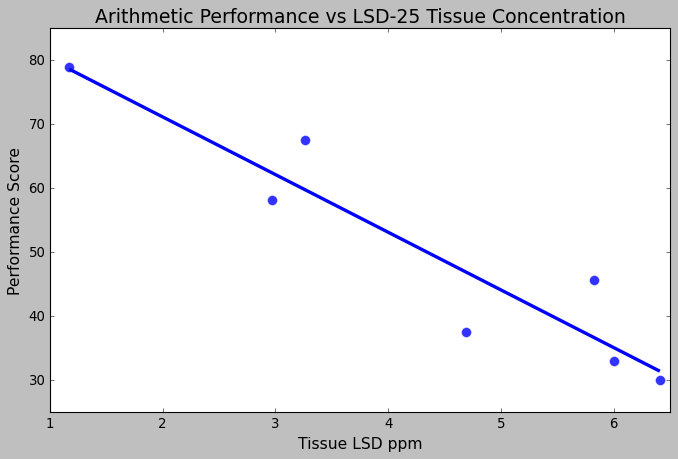

In [48]:
%matplotlib inline

plt.figure(figsize=(10,6))
plt.title('Arithmetic Performance vs LSD-25 Tissue Concentration', fontsize=17)
plt.xlabel('Tissue LSD ppm', fontsize=14)
plt.ylabel('Performance Score', fontsize=14)

plt.ylim(25, 85)
plt.xlim(1, 6.5)
plt.style.use('fivethirtyeight')

plt.scatter(LSD, score, s=80, alpha=0.8)
plt.plot(LSD, predicted_score, linewidth=3)
plt.show()

## 7. Conclusion

This analysis demonstrates a clear and strong negative correlation between **LSD tissue concentration** and **arithmetic test performance**.

### Key insights:
- Higher LSD concentration consistently predicts lower cognitive performance.
- The model explains ~88% of score variability.
- LSD likely impairs areas related to mathematical processing and attention.

### Limitations:
- Dataset is small and based on a controlled 1968 study.
- Only a univariate regression model was tested.
- Real-world effects may vary across individuals.

This notebook provides a simple but rigorous demonstration of linear regression applied to real experimental data.